# Capstone: Refresh and Content Opportunity Scoring

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oumaklaus/ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Which pages should a content team look at first next month, and can a model order that list better
than the rule they already use?**

This notebook is the whole track in one run. It reads the FlyRank warehouse once, builds the panel,
defines the label, scores the frozen Week 4 rule and the Week 5 forest on identical rows, walks the
same comparison up four validation designs, hunts its own leakage, and ends with a ranked queue and a
list of things the evidence refuses to support. The deployed paper is this notebook retold for a
reader; every number on that page comes from a cell below.

The short version of the result, so nothing below reads as a build up to good news. On a random split
the forest scores an AUC of about 0.76. Held out properly, on clients and a month it never saw, the
same model scores about 0.66 to 0.68. The honest number is the second one, and most of this notebook
is about why the first one is a mirage and what is left once you stop believing it.

## 1. Question

**The question.** For each published page, will its search impressions fall by more than 20 percent
next month, and can that be predicted well enough to order a review queue?

**The decision it supports.** A content team has more pages than review hours. Someone has to choose
which pages get opened first each month. Today that choice is made by sorting a spreadsheet by traffic,
or by a rule of thumb about page age. My work replaces the ordering of that list, and nothing else. It
does not decide what to change on a page, it does not publish, and it does not delete.

**Why decline and not growth.** Decline is the direction with a cheap intervention behind it. A page
that is falling can be reviewed and refreshed by a person who already knows the account. Growth needs
budget and new content. Also, decline is the more common event in this portfolio, which makes it the
easier target to measure honestly.

**Why this is a ranking problem and not a forecast.** The team can review perhaps twenty five to a few
hundred pages a month. What they need is the top of a list, not a probability per page. That framing
survives the validation results below; a calibrated per page probability does not.

**Scope.** One lane, Refresh and Content Opportunity Scoring. One unit of analysis: one page in one
month. One horizon: the next month.

In [1]:
# Setup. The token is read from the environment, Colab Secrets, or a prompt. It is NEVER written into
# this notebook, which lives in a public repo.
import os, json, duckdb, numpy as np, pandas as pd
pd.set_option("display.width", 230)

def _hf_token():
    tok = os.environ.get("HF_TOKEN")
    if tok:
        return tok
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        import getpass
        return getpass.getpass("HF read token: ")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{_hf_token()}')")

REL  = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
DIMC = f"{REL}/dim_content.parquet"
MONTHS = ["2026-03", "2026-04", "2026-05", "2026-06"]   # three labelled pairs plus the live month

def _repo_root():
    d = os.getcwd()
    for _ in range(6):
        if os.path.isdir(os.path.join(d, ".git")) or os.path.isdir(os.path.join(d, "work", "outputs")):
            return d
        d = os.path.dirname(d)
    return os.getcwd()

ROOT = _repo_root()
OUT  = os.path.join(ROOT, "work", "outputs")
FIG  = os.path.join(ROOT, "work", "figures")
os.makedirs(OUT, exist_ok=True); os.makedirs(FIG, exist_ok=True)
print("connected. outputs ->", OUT)
print("figures ->", FIG)

connected. outputs -> /home/zuko/ml-internship/work/outputs
figures -> /home/zuko/ml-internship/work/figures


## 2. Data

**Release.** The FlyRank ML internship warehouse on Hugging Face, gated, read token. Everything below
is aggregated in place over `hf://` with DuckDB. Nothing is downloaded and no page level data is
committed to this repo.

**Tables used.**

- `fact_content_daily_performance`, one row per report date, client and content item, partitioned by
  month. This is where impressions, clicks and summed position come from.
- `dim_content`, one row per content item. Creation date, publication and deletion flags, content type,
  intent, word count, and the keyword market columns.

**Tables deliberately not used.** `fact_content_daily_performance_sample` covers the final month only,
which is the natural outcome window of a past to future label, so developing against it means
developing inside the test window. `fact_content_query_90d` carries a fixed ninety day window that
overlaps my label month, and aligning that window safely was not worth the extra failure mode for a
page level monthly panel.

**Windows.** Features are aggregated inside one calendar month. The label is read from the month after.
Four months are pulled in one pass, which yields three labelled pairs and one live month:

| panel | features | label | role |
|---|---|---|---|
| P1 | 2026-03 | 2026-04 | the Week 5 training frame |
| P2 | 2026-04 | 2026-05 | first forward test |
| P3 | 2026-05 | 2026-06 | second forward test, and the fit that scores the queue |
| LIVE | 2026-06 | none yet | the queue, unlabelled by construction |

June is the last month the warehouse holds. It is used only as a test label and as the feature month of
the unlabelled queue. Nothing in the design was chosen by looking at it.

**Exclusions, and why.**

- `gsc_data_available IS FALSE` rows, and any page with zero impressions in the feature month. There is
  nothing to compare against. This is a survivor filter and section 5 measures what it costs.
- `content_updated_date`, `last_optimized_date`, `optimization_eligible_date`. Single snapshot values
  dated after my decision day for most rows, so their value at decision time is unrecoverable. The cell
  below prints the counts.
- The label's own ingredient, next month impressions, never enters the feature matrix. Section 3 proves
  the harness would notice if it did.
- No client names, domains, URLs or query text is read into this notebook at all. Identifiers are the
  warehouse's own hashes.

In [2]:
# Release verification first, the way the data skill asks: counts and date bounds before anything else.
rel = con.sql(f"""
    SELECT COUNT(*) AS fact_rows, MIN(report_date) AS first_day, MAX(report_date) AS last_day
    FROM read_parquet('{FACT}/*/*.parquet')
""").df()
dim_rows = con.sql(f"SELECT COUNT(*) AS n FROM read_parquet('{DIMC}')").df()["n"].iloc[0]
print("RELEASE")
print(f"  fact_content_daily_performance  {rel['fact_rows'].iloc[0]:,} rows, "
      f"{rel['first_day'].iloc[0]} to {rel['last_day'].iloc[0]}")
print(f"  dim_content                     {dim_rows:,} rows")

# One pass over the four months. Repeated full scans hit rate limits, so the aggregate runs once and
# every panel below is built from the frame it returns.
paths = ", ".join(f"'{FACT}/month={m}/*.parquet'" for m in MONTHS)

def month_cols(pre, lo, mid, hi):
    """Feature aggregates for one month, split at the 15th. Every term stays inside that month."""
    return f"""
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_impressions  ELSE 0 END) AS {pre}_impr,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_clicks       ELSE 0 END) AS {pre}_clicks,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{hi}' THEN gsc_sum_position ELSE 0 END) AS {pre}_sumpos,
       COUNT(*) FILTER (WHERE report_date BETWEEN DATE '{lo}' AND DATE '{hi}' AND gsc_impressions > 0) AS {pre}_days,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{mid}' THEN gsc_impressions ELSE 0 END) AS {pre}_h1_impr,
       SUM(CASE WHEN report_date >  DATE '{mid}' AND report_date <= DATE '{hi}' THEN gsc_impressions ELSE 0 END) AS {pre}_h2_impr,
       SUM(CASE WHEN report_date BETWEEN DATE '{lo}' AND DATE '{mid}' THEN gsc_clicks      ELSE 0 END) AS {pre}_h1_clicks,
       SUM(CASE WHEN report_date >  DATE '{mid}' AND report_date <= DATE '{hi}' THEN gsc_clicks      ELSE 0 END) AS {pre}_h2_clicks"""

w = con.sql(f"""
    SELECT content_hash_id,
      {month_cols('mar', '2026-03-01', '2026-03-15', '2026-03-31')},
      {month_cols('apr', '2026-04-01', '2026-04-15', '2026-04-30')},
      {month_cols('may', '2026-05-01', '2026-05-15', '2026-05-31')},
      {month_cols('jun', '2026-06-01', '2026-06-15', '2026-06-30')}
    FROM read_parquet([{paths}])
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
    ORDER BY content_hash_id   -- a hash aggregate returns rows in no fixed order, and row order
                               -- reaches the bootstrap sampler, so without this the third decimal
                               -- of every score moves between runs. Sorted, the notebook reproduces.
""").df()

dc = con.sql(f"""SELECT content_hash_id, client_hash_id, content_created_date, content_type,
                        main_intent, word_count, search_volume, cpc, is_published, is_deleted
                 FROM read_parquet('{DIMC}')""").df()
dc["content_created_date"] = pd.to_datetime(dc["content_created_date"])

def make_panel(pre, next_pre, decision_day):
    """Features from month `pre`, label from the month after. Neutral column names so one model
    definition fits any pair. next_pre=None builds the live month, which has no label yet."""
    p = pd.DataFrame({
        "content_hash_id": w["content_hash_id"],
        "impr":   w[f"{pre}_impr"],        "clicks":         w[f"{pre}_clicks"],
        "sumpos": w[f"{pre}_sumpos"],      "days_with_impr": w[f"{pre}_days"],
        "h1_impr":   w[f"{pre}_h1_impr"],  "h2_impr":        w[f"{pre}_h2_impr"],
        "h1_clicks": w[f"{pre}_h1_clicks"],"h2_clicks":      w[f"{pre}_h2_clicks"],
    })
    if next_pre:
        p["next_impr"] = w[f"{next_pre}_impr"]
    p = p[p["impr"] > 0].copy()
    p["ctr"]          = 100.0 * p["clicks"] / p["impr"]
    p["avg_position"] = p["sumpos"] / p["impr"]
    p["mom_impr"]     = (p["h2_impr"] + 1) / (p["h1_impr"] + 1)
    p["mom_clicks"]   = (p["h2_clicks"] + 1) / (p["h1_clicks"] + 1)
    p = p.merge(dc, on="content_hash_id", how="left")
    p["age_days"] = (pd.Timestamp(decision_day) - p["content_created_date"]).dt.days
    p = p[p["age_days"].notna()].copy()
    if next_pre:
        p["decline"] = (p["next_impr"] < 0.8 * p["impr"]).astype(int)
    return p.reset_index(drop=True)

P1   = make_panel("mar", "apr", "2026-03-31")
P2   = make_panel("apr", "may", "2026-04-30")
P3   = make_panel("may", "jun", "2026-05-31")
LIVE = make_panel("jun", None,  "2026-06-30")

panels = pd.DataFrame([
    {"panel": nm, "features": fm, "label": lm, "decision_day": dd, "pages": len(p),
     "clients": p["client_hash_id"].nunique(),
     "base_decline_rate": round(p["decline"].mean(), 4) if "decline" in p else np.nan}
    for nm, p, fm, lm, dd in (("P1", P1, "2026-03", "2026-04", "2026-03-31"),
                              ("P2", P2, "2026-04", "2026-05", "2026-04-30"),
                              ("P3", P3, "2026-05", "2026-06", "2026-05-31"),
                              ("LIVE", LIVE, "2026-06", "none yet", "2026-06-30"))])
print("\nPANELS, one recipe, four months")
print(panels.to_string(index=False))

# P1 and P2 must be the exact frames the weekly notebooks used, or nothing here compares to anything.
assert len(P1) == 176738 and round(P1["decline"].mean(), 4) == 0.5319, "P1 drifted from the ML-08 frame"
assert len(P2) == 194760 and round(P2["decline"].mean(), 4) == 0.5030, "P2 drifted from the ML-09 frame"
print("\ncheck: P1 and P2 reproduce the Week 5 and Week 6 frames exactly.")
for nm, pre in (("P1", "mar"), ("P2", "apr"), ("P3", "may"), ("LIVE", "jun")):
    gap = (w[f"{pre}_h1_impr"] + w[f"{pre}_h2_impr"] - w[f"{pre}_impr"]).abs().max()
    print(f"check: {nm} max |h1 + h2 - month total| = {gap:.1f}")

print("\nPOPULATION, from catalogue to panel")
print(f"  catalogued content items                          {dim_rows:,}")
print(f"  with GSC data and March impressions (P1)          {len(P1):,}  ({len(P1)/dim_rows:6.1%})")
print(f"  the filter therefore sets aside                   {dim_rows - len(P1):,} pages")
print("  Those pages are not low priority, they are invisible to this model. Section 5 measures the")
print("  age profile of that filter, because it is not age neutral.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RELEASE
  fact_content_daily_performance  78,835,655 rows, 2025-01-27 00:00:00 to 2026-06-30 00:00:00
  dim_content                     519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PANELS, one recipe, four months


panel features    label decision_day  pages  clients  base_decline_rate
   P1  2026-03  2026-04   2026-03-31 176738       47             0.5319
   P2  2026-04  2026-05   2026-04-30 194760       51             0.5030
   P3  2026-05  2026-06   2026-05-31 237910       56             0.7258
 LIVE  2026-06 none yet   2026-06-30 208636       55                NaN

check: P1 and P2 reproduce the Week 5 and Week 6 frames exactly.
check: P1 max |h1 + h2 - month total| = 0.0
check: P2 max |h1 + h2 - month total| = 0.0
check: P3 max |h1 + h2 - month total| = 0.0
check: LIVE max |h1 + h2 - month total| = 0.0

POPULATION, from catalogue to panel
  catalogued content items                          519,606
  with GSC data and March impressions (P1)          176,738  ( 34.0%)
  the filter therefore sets aside                   342,868 pages
  Those pages are not low priority, they are invisible to this model. Section 5 measures the
  age profile of that filter, because it is not age neutral.


## 3. Methodology

**The label.** A page declines if its impressions in the month after the feature month fall below
0.8 times its impressions in the feature month. Twenty percent is a threshold I chose, not one the data
handed me. It is wide enough to sit outside ordinary week to week noise on a trafficked page and narrow
enough to fire often enough to model. Section 5 says where that choice bites.

**The decision day.** The last day of the feature month. Every feature has to be knowable on that day.
That one rule is what excluded the three date columns in section 2, and it is the rule the leakage hunt
below is built to attack.

**The features, all ten.** Six static and four momentum, every term aggregated inside the feature month:

| feature | meaning |
|---|---|
| `impr`, `clicks` | month totals |
| `ctr` | clicks over impressions, as a percentage |
| `avg_position` | summed position over impressions, the impression weighted average |
| `days_with_impr` | days that month the page drew at least one impression |
| `age_days` | decision day minus creation date |
| `h1_impr`, `h2_impr` | impressions before and after the 15th |
| `mom_impr` | `(h2_impr + 1) / (h1_impr + 1)`, direction within the month |
| `mom_clicks` | the same ratio on clicks |

The plus one on both sides of the momentum ratio keeps it finite when a half month is empty. That
convenience has a consequence the leakage hunt found, and it is reported below rather than smoothed over.

Missing values are filled with zero at fit time. Pages with no creation date are dropped, because
`age_days` is undefined for them. The routing columns the panel also carries, publication flags and the
keyword market columns, are **not** features, and the next cell asserts that rather than trusting it.

**The baseline.** My frozen Week 4 rule, unchanged: score a page by its age in days if it drew at least
50 impressions and is at least 90 days old, otherwise zero. It is a real baseline rather than a straw
one, because it encodes the heuristic a team actually reaches for, and on a random split it looks
perfectly respectable.

**The model.** One random forest, 200 trees, `min_samples_leaf=100`, `random_state=42`. Chosen in Week 5
against logistic regression and a stratified dummy on the same folds, and frozen since. Nothing here
retunes it, because tuning against the forward test is exactly how an honest number becomes another
mirage.

**The validation design, as a ladder.** The same model and the same baseline scored four ways, each rung
removing one way the rung above it could flatter itself:

1. **Random split.** Rows shuffled. Pages of the same client land on both sides.
2. **Grouped by client.** No client in both train and test. Tests whether the model learned content
   behaviour or client fingerprints.
3. **Time forward.** Train on the earlier pair, test on the later one. Tests whether last month's
   pattern still holds next month.
4. **Grouped and time forward.** Unseen client and unseen month at once. This is the deployment
   condition, so this is the only number that counts.

Rung 4 then runs a second time on an independent pair, because a single forward test cannot separate
"the model does not travel" from "those two particular months differed".

In [3]:
from sklearn.model_selection import GroupKFold, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

STATIC = ["impr", "clicks", "ctr", "avg_position", "days_with_impr", "age_days"]
MOMENT = ["mom_impr", "mom_clicks", "h1_impr", "h2_impr"]
FEATS  = STATIC + MOMENT          # the ten Week 5 columns, nothing added, nothing retuned

# Guard the feature list against the panel's own convenience columns. The panel carries publication
# flags and keyword market columns for routing later; if one of them ever slipped in here the model
# would quietly stop being the model Week 5 validated.
assert FEATS == ["impr", "clicks", "ctr", "avg_position", "days_with_impr", "age_days",
                 "mom_impr", "mom_clicks", "h1_impr", "h2_impr"], "feature set drifted"
for extra in ("is_published", "is_deleted", "cpc", "search_volume", "word_count",
              "main_intent", "next_impr", "decline", "sumpos"):
    assert extra not in FEATS, f"{extra} leaked into the feature list"

def fit_rf(X, y):
    """The exact Week 5 model. One definition, used by every rung and by the deployed fit."""
    return RandomForestClassifier(n_estimators=200, min_samples_leaf=100,
                                  n_jobs=-1, random_state=42).fit(X, y)

def baseline_w04(df):
    """The frozen Week 4 rule, rescored on whatever rows it is handed."""
    flag = (df["impr"] >= 50) & (df["age_days"] >= 90)
    return np.where(flag, df["age_days"], 0).astype(float)

def p_at_k(scores, yy, k, tiebreak=None):
    """Precision in the top k. The rule ties thousands of rows on the same age, so it gets an explicit
    tiebreak on impressions instead of whatever order the array happened to arrive in."""
    tb = tiebreak if tiebreak is not None else np.zeros(len(scores))
    order = np.lexsort((-np.asarray(tb), -np.asarray(scores)))
    return np.asarray(yy)[order[:k]].mean()

def score_row(design, model, yy, sc, tb=None, fold=None):
    return {"design": design, "model": model, "fold": fold,
            "AUC": roc_auc_score(yy, sc), "PR_AUC": average_precision_score(yy, sc),
            "p@50": p_at_k(sc, yy, 50, tb), "p@500": p_at_k(sc, yy, 500, tb),
            "test_base": float(np.mean(yy)), "test_rows": int(len(yy))}

print("model: random forest, 200 trees, min_samples_leaf=100, random_state=42 (frozen in Week 5)")
print("baseline: age in days where impr >= 50 and age >= 90 days, else 0 (frozen in Week 4)")
print(f"features: {len(FEATS)} columns, {len(STATIC)} static and {len(MOMENT)} momentum")
print("check: no routing, market or label column is in the feature list.")

model: random forest, 200 trees, min_samples_leaf=100, random_state=42 (frozen in Week 5)
baseline: age in days where impr >= 50 and age >= 90 days, else 0 (frozen in Week 4)
features: 10 columns, 6 static and 4 momentum
check: no routing, market or label column is in the feature list.


### The leakage hunt

The ladder in section 4 says the model beats the rule. Before believing that I attacked my own features.
Four tests: one to prove the rig can detect leakage at all, one to remove the prime suspect, one to break
the arithmetic that the label and the features share, and one to confirm the excluded date columns really
are unusable rather than merely inconvenient.

The suspect is `mom_impr`. The label compares next month's impressions against this month's total, and
`mom_impr` compares the two halves of this month's total. They share a term. A model can look clever
purely by reading a number that is already inside the answer.

In [4]:
gkf = GroupKFold(n_splits=5)
tr_i, te_i = next(iter(gkf.split(P1[FEATS], P1["decline"], P1["client_hash_id"])))

def auc_with(cols, tr=tr_i, te=te_i, frame=None, y=None):
    """One grouped fold, one feature set, one number. The same fold every time, so the only thing
    changing between lines is the feature list."""
    f = P1 if frame is None else frame
    yy = f["decline"].values if y is None else y
    X = f[cols].fillna(0.0)
    return roc_auc_score(yy[te], fit_rf(X.iloc[tr], yy[tr]).predict_proba(X.iloc[te])[:, 1])

honest = auc_with(FEATS)
leaky  = auc_with(FEATS + ["next_impr"])
print("A. POSITIVE CONTROL, can this harness see leakage at all")
print(f"   the ten honest features                                    AUC {honest:.4f}")
print(f"   plus next month's impressions, the label's own ingredient   AUC {leaky:.4f}")
print(f"   the rig moves {leaky - honest:+.4f} when handed the answer, so it would notice a real leak.\n")

no_mom = auc_with([c for c in FEATS if c != "mom_impr"])
static = auc_with(STATIC)
print("B. THE SUSPECT, remove momentum and watch whether the model collapses or merely weakens")
print(f"   all ten features   AUC {honest:.4f}")
print(f"   without mom_impr   AUC {no_mom:.4f}   ({no_mom - honest:+.4f})")
print(f"   the static six     AUC {static:.4f}   ({static - honest:+.4f})")
print("   Leakage looks like a fall from near 1.0. This is a modest number getting weaker, which is")
print("   what a genuinely useful feature looks like, not a label wearing a disguise.\n")

# C. Break the shared term. March features, but a label that compares May against April, so label and
# features have no month in common at all.
D = P1.merge(pd.DataFrame({"content_hash_id": w["content_hash_id"],
                           "apr_impr": w["apr_impr"], "may_impr": w["may_impr"]}),
             on="content_hash_id", how="inner")
D = D[D["apr_impr"] > 0].reset_index(drop=True)
D["decline_decoupled"] = (D["may_impr"] < 0.8 * D["apr_impr"]).astype(int)
dtr, dte = next(iter(gkf.split(D[FEATS], D["decline_decoupled"], D["client_hash_id"])))
auc_dec = auc_with(FEATS, dtr, dte, D, D["decline_decoupled"].values)
print("C. ARITHMETIC COUPLING, a label that shares no month with the features")
print(f"   pages {len(D):,}   decoupled base rate {D['decline_decoupled'].mean():.4f}")
print(f"   March features, April vs March label (shares the March total)   AUC {honest:.4f}")
print(f"   March features, May vs April label   (shares nothing)           AUC {auc_dec:.4f}")

q = pd.qcut(D["mom_impr"], 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
tbl = D.groupby(q, observed=True).agg(pages=("decline", "size"),
                                      under_original_label=("decline", "mean"),
                                      under_decoupled_label=("decline_decoupled", "mean")).round(3)
print("\n   Decline rate by March momentum quartile, under both labels:")
print(tbl.to_string())
print("\n   The AUC barely moves and the direction inverts. Under the original label the falling page is")
print("   likelier to decline; under the decoupled label the rising page is. A forest learns whichever")
print("   direction its training data shows, so a stable AUC across that flip does not validate the")
print("   reading I had put on the feature. The ranking survives the test. The story I told about it")
print("   does not, and section 5 keeps it out of the paper's claims.")

print("\nD. THE EXCLUDED DATE COLUMNS, checked against the decision day rather than assumed")
for colname in ("content_updated_date", "last_optimized_date", "optimization_eligible_date"):
    r = con.sql(f"""SELECT COUNT(*) AS nn,
                           COUNT(*) FILTER (WHERE {colname} > DATE '2026-03-31') AS after_day
                    FROM read_parquet('{DIMC}') WHERE {colname} IS NOT NULL""").df()
    nn, af = int(r["nn"].iloc[0]), int(r["after_day"].iloc[0])
    print(f"   {colname:28s} {af:,} of {nn:,} non null values fall after the decision day ({af/nn:.1%})")
print("   dim_content holds one snapshot value per page, so whatever these columns held on 2026-03-31")
print("   is unrecoverable. Not usable, therefore excluded rather than imputed.")

A. POSITIVE CONTROL, can this harness see leakage at all
   the ten honest features                                    AUC 0.6428
   plus next month's impressions, the label's own ingredient   AUC 0.9749
   the rig moves +0.3321 when handed the answer, so it would notice a real leak.



B. THE SUSPECT, remove momentum and watch whether the model collapses or merely weakens
   all ten features   AUC 0.6428
   without mom_impr   AUC 0.6159   (-0.0269)
   the static six     AUC 0.5802   (-0.0626)
   Leakage looks like a fall from near 1.0. This is a modest number getting weaker, which is
   what a genuinely useful feature looks like, not a label wearing a disguise.



C. ARITHMETIC COUPLING, a label that shares no month with the features
   pages 158,549   decoupled base rate 0.5433
   March features, April vs March label (shares the March total)   AUC 0.6428
   March features, May vs April label   (shares nothing)           AUC 0.6610



   Decline rate by March momentum quartile, under both labels:
            pages  under_original_label  under_decoupled_label
mom_impr                                                      
Q1 lowest   39846                 0.676                  0.476
Q2          39554                 0.547                  0.518
Q3          39523                 0.401                  0.547
Q4 highest  39626                 0.287                  0.632

   The AUC barely moves and the direction inverts. Under the original label the falling page is
   likelier to decline; under the decoupled label the rising page is. A forest learns whichever
   direction its training data shows, so a stable AUC across that flip does not validate the
   reading I had put on the feature. The ranking survives the test. The story I told about it
   does not, and section 5 keeps it out of the paper's claims.

D. THE EXCLUDED DATE COLUMNS, checked against the decision day rather than assumed


   content_updated_date         382,739 of 519,606 non null values fall after the decision day (73.7%)


   last_optimized_date          45,396 of 45,396 non null values fall after the decision day (100.0%)


   optimization_eligible_date   45,396 of 45,396 non null values fall after the decision day (100.0%)
   dim_content holds one snapshot value per page, so whatever these columns held on 2026-03-31
   is unrecoverable. Not usable, therefore excluded rather than imputed.


## 4. Results

Model against baseline, on the same rows, at every rung. The base rate is printed beside each number,
because on this panel a coin that always says decline is right about half the time and any accuracy
figure without the base rate next to it is decoration.

In [5]:
ladder = []

# RUNG 1, random split. Pages of the same client land on both sides, which is the flattering mistake.
X1, y1 = P1[FEATS].fillna(0.0), P1["decline"].values
for f, (tr, te) in enumerate(KFold(n_splits=5, shuffle=True, random_state=42).split(X1)):
    m = fit_rf(X1.iloc[tr], y1[tr])
    ladder.append(score_row("1 random, Mar>Apr", "rf_momentum", y1[te],
                            m.predict_proba(X1.iloc[te])[:, 1], fold=f))
    ladder.append(score_row("1 random, Mar>Apr", "baseline_w04", y1[te],
                            baseline_w04(P1.iloc[te]), P1["impr"].values[te], fold=f))

# RUNG 2, grouped by client. No client on both sides of the split.
g1 = P1["client_hash_id"].values
for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(X1, y1, g1)):
    m = fit_rf(X1.iloc[tr], y1[tr])
    ladder.append(score_row("2 grouped, Mar>Apr", "rf_momentum", y1[te],
                            m.predict_proba(X1.iloc[te])[:, 1], fold=f))
    ladder.append(score_row("2 grouped, Mar>Apr", "baseline_w04", y1[te],
                            baseline_w04(P1.iloc[te]), P1["impr"].values[te], fold=f))

# RUNG 3, time forward. Train on the whole earlier pair, test on the whole later one. Clients overlap
# on purpose here, so the only thing held out is time.
mdl_t = fit_rf(X1, y1)
X2, y2 = P2[FEATS].fillna(0.0), P2["decline"].values
ladder.append(score_row("3 time fwd, Apr>May", "rf_momentum", y2, mdl_t.predict_proba(X2)[:, 1]))
ladder.append(score_row("3 time fwd, Apr>May", "baseline_w04", y2, baseline_w04(P2), P2["impr"].values))

def forward_pair(Ptr, Pte, design):
    """RUNG 4. Unseen client and unseen month at once, which is the deployment condition. Also returns
    an out of fold p_decline for every row of the later panel, so every downstream number in sections 5
    and 6 is measured on rows whose client the scoring model had never seen."""
    Xtr, ytr, gtr = Ptr[FEATS].fillna(0.0), Ptr["decline"].values, Ptr["client_hash_id"].values
    Xte, yte, gte = Pte[FEATS].fillna(0.0), Pte["decline"].values, Pte["client_hash_id"].values
    oof, rows, fold0 = np.full(len(Pte), np.nan), [], None
    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(Xtr, ytr, gtr)):
        m = fit_rf(Xtr.iloc[tr], ytr[tr])
        if fold0 is None:
            fold0 = m
        mask = np.isin(gte, list(set(gtr[te])))      # only clients this fold never trained on
        if mask.sum() < 500:
            continue
        p = m.predict_proba(Xte[mask])[:, 1]
        oof[mask] = p
        rows.append(score_row(design, "rf_momentum", yte[mask], p, fold=f))
        rows.append(score_row(design, "baseline_w04", yte[mask],
                              baseline_w04(Pte[mask]), Pte["impr"].values[mask], fold=f))
    # Clients in the later panel that were absent from the earlier one sat in no fold at all. Fold 0
    # never saw them either, so it scores them, and the count gets printed rather than buried.
    orphan = np.isnan(oof)
    if orphan.any():
        oof[orphan] = fold0.predict_proba(Xte[orphan])[:, 1]
    return rows, oof, int(orphan.sum()), fold0

r4a, oof2, orph2, _      = forward_pair(P1, P2, "4 grouped+time, pair 1 Apr>May")
r4b, oof3, orph3, m_last = forward_pair(P2, P3, "4 grouped+time, pair 2 May>Jun")
ladder += r4a + r4b
P2 = P2.assign(p_decline=oof2)
P3 = P3.assign(p_decline=oof3)

L = pd.DataFrame(ladder)
num = ["AUC", "PR_AUC", "p@50", "p@500", "test_base"]
lad_mean = L.groupby(["design", "model"], sort=True)[num].mean().round(3)
lad_std  = L.groupby(["design", "model"], sort=True)[num].std().round(3)
print("THE VALIDATION LADDER, one model and one baseline, four designs")
print("each rung removes one way the rung above it could flatter itself\n")
print(lad_mean.to_string())
print("\nspread across folds, where the rung has folds")
print(lad_std[["AUC", "p@500"]].to_string())
print(f"\nrows whose client was absent from the training pair entirely: {orph2:,} and {orph3:,}")
print("scored by fold 0, which had never seen them either.")

# Reproducibility: the Week 6 notebook ran rungs 1 to 4 on the same panels and committed its numbers.
w06 = {("1 random, Mar>Apr", "rf_momentum"): 0.763, ("1 random, Mar>Apr", "baseline_w04"): 0.513,
       ("2 grouped, Mar>Apr", "rf_momentum"): 0.671, ("2 grouped, Mar>Apr", "baseline_w04"): 0.532,
       ("3 time fwd, Apr>May", "rf_momentum"): 0.690, ("3 time fwd, Apr>May", "baseline_w04"): 0.509}
print("\nREPRODUCIBILITY, this run against the numbers Week 6 committed")
for k, v in w06.items():
    got = lad_mean.loc[k, "AUC"]
    print(f"  {k[0]:22s} {k[1]:14s} now {got:.3f}   Week 6 {v:.3f}   diff {got - v:+.3f}")

r4 = lad_mean.loc[[i for i in lad_mean.index if i[0].startswith("4 ")]]
print("\nTHE NUMBER THAT COUNTS, rung 4 on two independent pairs")
print(r4.to_string())
lift = (r4.xs("rf_momentum", level=1)["AUC"].mean()
        - r4.xs("baseline_w04", level=1)["AUC"].mean())
print(f"\nmean forward AUC, model {r4.xs('rf_momentum', level=1)['AUC'].mean():.3f} "
      f"vs baseline {r4.xs('baseline_w04', level=1)['AUC'].mean():.3f}, a gap of {lift:+.3f}")
print("Both pairs put the model ahead of the rule, and both put it far below the random split figure.")

THE VALIDATION LADDER, one model and one baseline, four designs
each rung removes one way the rung above it could flatter itself

                                               AUC  PR_AUC   p@50  p@500  test_base
design                         model                                               
1 random, Mar>Apr              baseline_w04  0.515   0.533  0.960  0.615      0.532
                               rf_momentum   0.764   0.773  0.960  0.938      0.532
2 grouped, Mar>Apr             baseline_w04  0.532   0.579  0.568  0.622      0.532
                               rf_momentum   0.671   0.673  0.892  0.774      0.532
3 time fwd, Apr>May            baseline_w04  0.509   0.483  0.580  0.578      0.503
                               rf_momentum   0.690   0.698  0.980  0.972      0.503
4 grouped+time, pair 1 Apr>May baseline_w04  0.512   0.507  0.324  0.383      0.509
                               rf_momentum   0.679   0.673  0.916  0.867      0.509
4 grouped+time, pair 2 May>Jun

### What the ladder says

Read the AUC column top to bottom. The model scores about 0.76 on a random split and about 0.67 once no
client sits on both sides. The same features, the same trees, the same rows: a third of the apparent
skill was the model recognising clients rather than reading content behaviour. If I had shipped the
random split number I would have promised roughly 0.76 and delivered roughly 0.67.

The baseline does not move. It never leaves the 0.48 to 0.53 band at any rung, which is what a coin
looks like. That is
the honest comparison: the model is not impressive, but it is measurably better than the heuristic it
would replace, and it stays better when both are scored on clients and a month neither had seen.

`p@50` is the one place the rule looks good on a random split, at 0.96, and it is an artefact. The rule
assigns thousands of pages the identical score, so the top 50 is whatever the tiebreak returns; hand it
an unseen client and the same figure falls to about 0.32. A metric that swings that far on a tiebreak is
not measuring the rule.

**Nothing below this line uses a model that ever saw the client it is scoring.** Every `p_decline` in
sections 5 and 6 is out of fold.

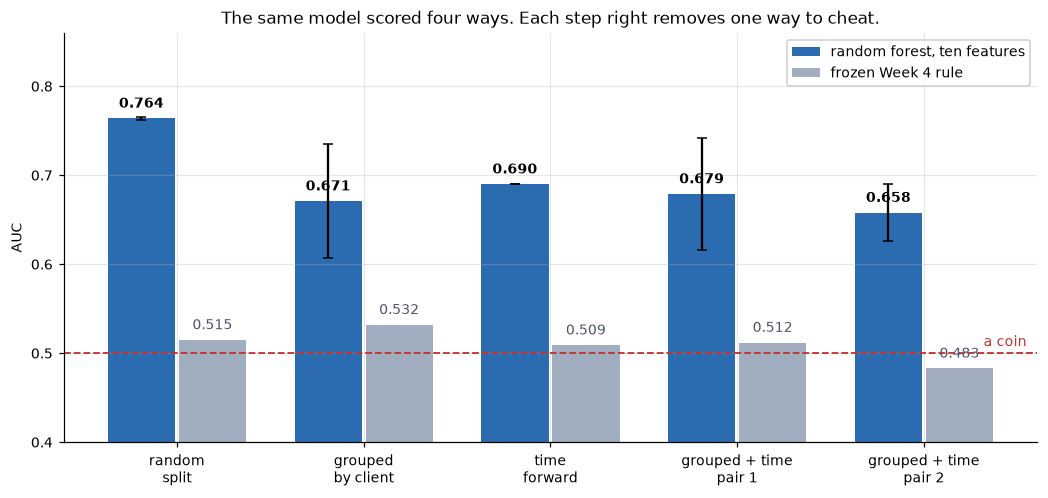

Takeaway: a third of the model's apparent skill was client recognition, and the rule it replaces
never leaves coin flip territory at any rung.



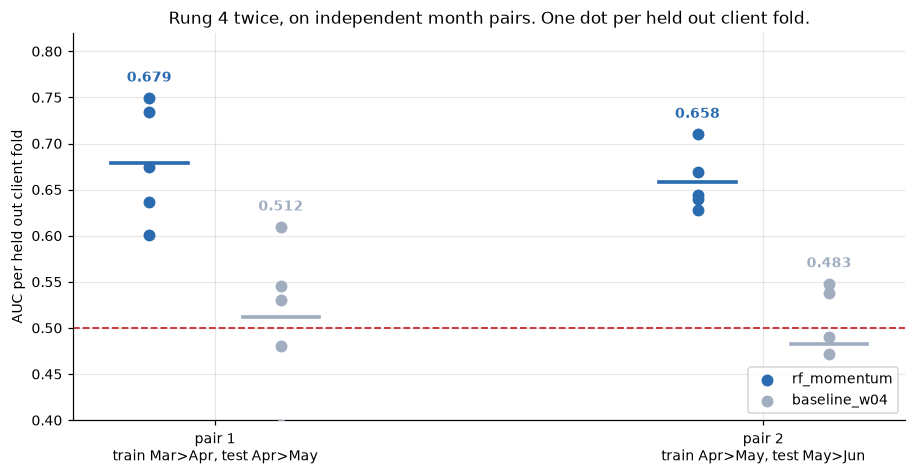

Takeaway: the forward result repeats on a pair it was not tuned on, so it is a property of the
model rather than of two convenient months. The fold spread is wide, so the honest way to quote
it is a range rather than a single decimal.


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

# FIGURE 1, the mirage. The single chart this paper is built around.
order = ["1 random, Mar>Apr", "2 grouped, Mar>Apr", "3 time fwd, Apr>May",
         "4 grouped+time, pair 1 Apr>May", "4 grouped+time, pair 2 May>Jun"]
short = ["random\nsplit", "grouped\nby client", "time\nforward", "grouped + time\npair 1",
         "grouped + time\npair 2"]
rf = [lad_mean.loc[(d, "rf_momentum"), "AUC"] for d in order]
bl = [lad_mean.loc[(d, "baseline_w04"), "AUC"] for d in order]
rfe = [lad_std.loc[(d, "rf_momentum"), "AUC"] for d in order]
rfe = [0 if pd.isna(v) else v for v in rfe]

fig, ax = plt.subplots(figsize=(9.6, 4.6))
xs = np.arange(len(order))
ax.bar(xs - 0.19, rf, 0.36, yerr=rfe, capsize=3, color="#2b6cb0", label="random forest, ten features")
ax.bar(xs + 0.19, bl, 0.36, color="#a0aec0", label="frozen Week 4 rule")
ax.axhline(0.5, color="#c53030", ls="--", lw=1.2)
ax.text(len(order) - 0.45, 0.508, "a coin", color="#c53030", fontsize=9, ha="right")
for x, v in zip(xs - 0.19, rf):
    ax.text(x, v + 0.012, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
for x, v in zip(xs + 0.19, bl):
    ax.text(x, v + 0.012, f"{v:.3f}", ha="center", fontsize=9, color="#4a5568")
ax.set_xticks(xs); ax.set_xticklabels(short, fontsize=9)
ax.set_ylabel("AUC"); ax.set_ylim(0.40, 0.86)
ax.set_title("The same model scored four ways. Each step right removes one way to cheat.", fontsize=11)
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{FIG}/w08_ladder.png", dpi=150); plt.show()
print("Takeaway: a third of the model's apparent skill was client recognition, and the rule it replaces")
print("never leaves coin flip territory at any rung.\n")

# FIGURE 2, does the forward number hold on an independent pair. Fold level, not just the mean.
fig, ax = plt.subplots(figsize=(8.4, 4.4))
pairs = ["4 grouped+time, pair 1 Apr>May", "4 grouped+time, pair 2 May>Jun"]
labels = ["pair 1\ntrain Mar>Apr, test Apr>May", "pair 2\ntrain Apr>May, test May>Jun"]
for i, d in enumerate(pairs):
    for mname, colr, off in (("rf_momentum", "#2b6cb0", -0.12), ("baseline_w04", "#a0aec0", 0.12)):
        sub = L[(L["design"] == d) & (L["model"] == mname)]
        ax.scatter(np.full(len(sub), i + off), sub["AUC"], s=46, color=colr, zorder=3,
                   label=mname if i == 0 else None)
        ax.plot([i + off - 0.07, i + off + 0.07], [sub["AUC"].mean()] * 2, color=colr, lw=2.4, zorder=4)
        ax.text(i + off, sub["AUC"].max() + 0.018, f"{sub['AUC'].mean():.3f}",
                ha="center", fontsize=9, fontweight="bold", color=colr)
ax.axhline(0.5, color="#c53030", ls="--", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("AUC per held out client fold"); ax.set_ylim(0.40, 0.82)
ax.set_title("Rung 4 twice, on independent month pairs. One dot per held out client fold.", fontsize=11)
ax.legend(loc="lower right", fontsize=9); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{FIG}/w08_forward_stability.png", dpi=150); plt.show()
print("Takeaway: the forward result repeats on a pair it was not tuned on, so it is a property of the")
print("model rather than of two convenient months. The fold spread is wide, so the honest way to quote")
print("it is a range rather than a single decimal.")

## 5. Limitations and honest framing

Six limits, each with the measurement that establishes it in the next cell rather than an assurance.

**1. `p_decline` is a rank, not a chance.** The forest is uncalibrated and nothing here calibrates it.
The reliability table below shows what the score is worth, and it is less than I would like: the two
ends of the range separate clearly, adjacent buckets do not order reliably, and the level is off by as
much as 0.42 because the model was fitted near a 0.53 base rate and scored on a month where 0.73 of
pages fell. So the
score never appears in a sentence like "this page has a 72 percent chance of declining". It appears as a
position in a list, and every cutoff in section 6 is a review capacity rather than a probability
threshold.

**2. The model only sees survivors.** The panel needs impressions in the feature month, which throws away
most of the catalogue. The age profile below shows the filter is not age neutral, so the population the
queue speaks about is systematically different from the catalogue it was drawn from. A page with no
impressions is invisible to this model, and invisible is not the same as unimportant.

**3. The base rate moves more than the model does.** Across the three labelled pairs the decline rate
runs from about 0.50 to about 0.73. That spread is not a modelling result, it is what happened, and
it means the same queue at the same length would look far more precise in June than in April purely
because more pages fell. Precision figures are only readable against the base rate printed beside them.

**4. Momentum's direction is not established.** The leakage hunt in section 3 found that the relationship
between within month momentum and next month decline inverts when the label is decoupled. The ranking
survives that test; the interpretation does not. So this paper does not claim that falling pages keep
falling. It claims the ordering is useful, which is a smaller and defensible claim.

**5. No causal claim, anywhere.** Nothing here shows that refreshing a page changes its traffic. The
warehouse has no experiment, no holdout, no randomisation over refresh decisions. Pages that get
refreshed are chosen, and choosing is a cause of its own. Every result in this paper is an association
observed on this data over these months, and the language stays at observed, measured, associated with,
directional, and decision support.

**6. One release, four months of it, one lane.** The panels cover 2026-03 to 2026-06. Seasonality is
unmeasurable in four months. The forward result was checked on two pairs, which is enough to show it is
not a fluke of one pair and not enough to call it stable. A third pair would help. There is not one.

**What would change my mind.** If the forward AUC on a new pair falls below the frozen rule plus 0.05,
the model is not earning its complexity and the rule should ship instead. If a review log ever shows
reviewers disagreeing with the reason code more than 30 percent of the time, the archetype thresholds
are wrong rather than the ranking. Both triggers are in the monitoring table in section 6.

In [7]:
# LIMIT 1. Is p_decline a probability? Out of fold scores on P3, bucketed, predicted against observed.
cal = P3.assign(bucket=pd.qcut(P3["p_decline"], 10, labels=False, duplicates="drop"))
calib = cal.groupby("bucket").agg(pages=("decline", "size"),
                                mean_p_decline=("p_decline", "mean"),
                                observed_decline=("decline", "mean")).round(3)
calib["gap"] = (calib["mean_p_decline"] - calib["observed_decline"]).round(3)
print("CALIBRATION, out of fold scores on the May to June panel, ten equal size buckets")
print(calib.to_string())
mono = calib["observed_decline"].is_monotonic_increasing
print(f"\nobserved decline rate rises monotonically across buckets: {mono}")
print(f"largest gap between mean score and observed rate: {calib['gap'].abs().max():.3f}")
print("The ordering is sound and the level is not, which is exactly the definition of a usable rank and")
print("an unusable probability. Hence: rank only, and every cutoff below is a review capacity.\n")

# LIMIT 2. Who the survivor filter removes. Age profile of the catalogue against the scored population.
surv = dc.merge(pd.DataFrame({"content_hash_id": w["content_hash_id"], "jun_impr": w["jun_impr"]}),
                on="content_hash_id", how="left")
surv["jun_impr"] = surv["jun_impr"].fillna(0)
surv["age_days"] = (pd.Timestamp("2026-06-30") - surv["content_created_date"]).dt.days
bands = pd.cut(surv["age_days"], [-1, 90, 180, 365, 730, 10**6],
               labels=["0 to 90d", "91 to 180d", "181 to 365d", "1 to 2y", "over 2y"])
sv = surv.groupby(bands, observed=True).agg(
        catalogued=("content_hash_id", "size"),
        scored=("jun_impr", lambda s: int((s > 0).sum())))
sv["share_scored"] = (sv["scored"] / sv["catalogued"]).round(3)
print("THE SURVIVOR FILTER, by age band on the live month's decision day")
print(sv.to_string())
print(f"\ncatalogue {len(surv):,} pages, scored in the live month {int((surv['jun_impr'] > 0).sum()):,} "
      f"({(surv['jun_impr'] > 0).mean():.1%})")
print(f"pages with no creation date, so absent from the bands above: "
      f"{int(surv['content_created_date'].isna().sum()):,}")
print("The retention rate is not flat across the bands, so the scored population is not a random sample")
print("of the catalogue. Any statement about 'content' in this paper means 'content that drew")
print("impressions that month', and the two are not the same population.\n")

# LIMIT 3. Base rate movement, the thing that moves more than the model does.
bases = pd.DataFrame([{"pair": nm, "features": fm, "label": lm, "pages": len(p),
                       "base_decline_rate": round(float(p["decline"].mean()), 4)}
                      for nm, p, fm, lm in (("P1", P1, "2026-03", "2026-04"),
                                            ("P2", P2, "2026-04", "2026-05"),
                                            ("P3", P3, "2026-05", "2026-06"))])
print("BASE RATE ACROSS THE THREE LABELLED PAIRS")
print(bases.to_string(index=False))
spread = bases["base_decline_rate"].max() - bases["base_decline_rate"].min()
print(f"\nspread {spread:.3f}, against a forward AUC gap over the baseline of roughly 0.17.")
print("The month a queue is measured in moves its precision more than the choice of model does, which")
print("is why every precision number in section 6 is printed next to the base rate of its own pool.")

# LIMIT 6. The window, stated as data rather than as a caveat.
span = con.sql(f"""SELECT MIN(report_date) AS a, MAX(report_date) AS b,
                          COUNT(DISTINCT date_trunc('month', report_date)) AS months
                   FROM read_parquet('{FACT}/*/*.parquet')""").df()
print(f"\nWINDOW: the release spans {span['a'].iloc[0]} to {span['b'].iloc[0]}, "
      f"{int(span['months'].iloc[0])} calendar months.")
print("This work uses the last four. Four months cannot separate a seasonal pattern from a trend, so no")
print("sentence in this paper attributes anything to a season.")

CALIBRATION, out of fold scores on the May to June panel, ten equal size buckets
        pages  mean_p_decline  observed_decline    gap
bucket                                                
0       23791           0.142             0.450 -0.308
1       23791           0.250             0.633 -0.383
2       24281           0.311             0.735 -0.424
3       23301           0.353             0.662 -0.309
4       23791           0.412             0.719 -0.307
5       23791           0.462             0.740 -0.278
6       23791           0.513             0.776 -0.263
7       23791           0.578             0.805 -0.227
8       23791           0.673             0.842 -0.169
9       23791           0.820             0.896 -0.076

observed decline rate rises monotonically across buckets: False
largest gap between mean score and observed rate: 0.424
The ordering is sound and the level is not, which is exactly the definition of a usable rank and
an unusable probability. Hence: rank only

THE SURVIVOR FILTER, by age band on the live month's decision day
             catalogued  scored  share_scored
age_days                                     
0 to 90d          82317   49063         0.596
91 to 180d        78887   55222         0.700
181 to 365d      191432   71641         0.374
1 to 2y          163115   32674         0.200

catalogue 519,606 pages, scored in the live month 208,636 (40.2%)
pages with no creation date, so absent from the bands above: 0
The retention rate is not flat across the bands, so the scored population is not a random sample
of the catalogue. Any statement about 'content' in this paper means 'content that drew
impressions that month', and the two are not the same population.

BASE RATE ACROSS THE THREE LABELLED PAIRS
pair features   label  pages  base_decline_rate
  P1  2026-03 2026-04 176738             0.5319
  P2  2026-04 2026-05 194760             0.5030
  P3  2026-05 2026-06 237910             0.7258

spread 0.223, against a forward AUC gap ov

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


WINDOW: the release spans 2025-01-27 00:00:00 to 2026-06-30 00:00:00, 18 calendar months.
This work uses the last four. Four months cannot separate a seasonal pattern from a trend, so no
sentence in this paper attributes anything to a season.


## 6. Ranked recommendations, the playbook

A ranking on its own is not an action. Two pages can share a `p_decline` of 0.8 and need entirely
different work: one is a heavy earner losing ground inside the month, the other ranks on page two and has
never been touched. So the score decides the order and a routing layer decides the verb.

Nine archetypes, evaluated in order, **first match wins**, so each page carries exactly one reason. Two
of the nine are hard exclusions and come first on purpose, because a queue that recommends work on a
deleted page burns the reviewer's trust in everything below it.

| # | archetype | condition | action |
|---|---|---|---|
| 1 | `not_live` | catalogue says unpublished or deleted | **drop from queue** |
| 2 | `no_baseline` | no first half impressions, so momentum is undefined | **human look, no recommendation** |
| 3 | `thin_traffic` | under 50 impressions in the month | no action, below the measurement floor |
| 4 | `slipping_workhorse` | 500 or more impressions and falling within the month | refresh, senior review |
| 5 | `stale_but_visible` | 90 days or older and flat or down | queue for refresh |
| 6 | `position_stuck` | average position between 11 and 25 | on page optimisation |
| 7 | `ctr_gap` | on page one but click share below the April median | title and snippet review |
| 8 | `young_climbing` | under 90 days and rising | monitor only, too young to judge |
| 9 | `steady` | nothing above matched | no action |

Order matters and the order is deliberate. Rule 3 fires before rules 4 to 8, so every recommendation
inherits the 50 impression floor. Rule 4 fires before rule 5, so a heavy earner is never quietly filed as
routine maintenance.

Only four of the nine carry a recommendation. Silence on the other five is the design working, not a gap
to be filled by lowering the floor.

**Ranking.** `priority = p_decline x impressions`, ranked **inside each client**. Week 4 measured that a
single portfolio wide sort put all 100 of the global top 100 rows inside one account, which is a report
about account size rather than a work queue. Per client ranking is what a team can actually act on.

The deployed fit is the newest labelled pair, May features against a June label, scoring the June feature
month, which has no label and will not have one until July data lands.

In [8]:
TRAFFIC_FLOOR, BIG_TRAFFIC, MOM_FALL = 50, 500, 0.8
POS_LO, POS_HI, AGE_LINE = 11.0, 25.0, 90

# The CTR floor comes from the April panel: earlier than the panel these rates are measured on and
# earlier than the month the queue scores, so it is not tuned on rows it is applied to.
first_page = (P2["avg_position"] > 0) & (P2["avg_position"] <= 10) & (P2["impr"] >= TRAFFIC_FLOOR)
CTR_FLOOR = float(P2.loc[first_page, "ctr"].median())

ARCH = [
    ("1 not_live",           "drop_from_queue",       "page_not_live",
     lambda d: d["is_published"].eq(False) | d["is_deleted"].eq(True)),
    ("2 no_baseline",        "human_look_no_rec",     "no_first_half_baseline",
     lambda d: d["h1_impr"].eq(0)),
    ("3 thin_traffic",       "no_action",             "below_measurement_floor",
     lambda d: d["impr"] < TRAFFIC_FLOOR),
    ("4 slipping_workhorse", "refresh_senior_review", "high_traffic_falling_within_month",
     lambda d: (d["impr"] >= BIG_TRAFFIC) & (d["mom_impr"] < MOM_FALL)),
    ("5 stale_but_visible",  "queue_for_refresh",     "aged_visible_and_flat_or_down",
     lambda d: (d["age_days"] >= AGE_LINE) & (d["mom_impr"] < 1.0)),
    ("6 position_stuck",     "on_page_optimisation",  "ranks_just_off_first_page",
     lambda d: d["avg_position"].between(POS_LO, POS_HI)),
    ("7 ctr_gap",            "title_snippet_review",  "visible_but_low_click_share",
     lambda d: (d["avg_position"] > 0) & (d["avg_position"] <= 10) & (d["ctr"] < CTR_FLOOR)),
    ("8 young_climbing",     "monitor_only",          "too_young_to_judge",
     lambda d: (d["age_days"] < AGE_LINE) & (d["mom_impr"] >= 1.0)),
    ("9 steady",             "no_action",             "no_trigger_matched", None),
]
ACTION = {a: act for a, act, _, _ in ARCH}
REASON = {a: rsn for a, _, rsn, _ in ARCH}
CARRIES_REC = {"refresh_senior_review", "queue_for_refresh", "on_page_optimisation",
               "title_snippet_review"}

def assign(d):
    """First match wins, so one page carries one reason."""
    out, unset = pd.Series(ARCH[-1][0], index=d.index, dtype=object), pd.Series(True, index=d.index)
    for nm, _, _, fn in ARCH[:-1]:
        hit = unset & fn(d)
        out[hit] = nm
        unset &= ~hit
    return out

for p in (P2, P3, LIVE):
    p["archetype"]   = assign(p)
    p["action"]      = p["archetype"].map(ACTION)
    p["reason_code"] = p["archetype"].map(REASON)

print(f"CTR floor from the April panel, first page rows only: {CTR_FLOOR:.2f} percent")
print(f"pages with June impressions that the catalogue calls unpublished or deleted: "
      f"{int(LIVE['archetype'].eq('1 not_live').sum()):,} of {len(LIVE):,}, carrying "
      f"{int(LIVE.loc[LIVE['archetype'].eq('1 not_live'), 'impr'].sum()):,} June impressions.")
print("Those are dropped before any recommendation, which is the single highest value rule in the list.")

base3 = float(P3["decline"].mean())
tab = P3.groupby("archetype").agg(pages=("decline", "size"), decline_rate=("decline", "mean"),
                                  median_impr=("impr", "median"), impressions=("impr", "sum"),
                                  mean_score=("p_decline", "mean"))
tab["share_of_pages"] = (tab["pages"] / len(P3)).round(3)
tab["lift_vs_base"]   = (tab["decline_rate"] / base3).round(2)
tab["decline_rate"]   = tab["decline_rate"].round(3)
tab["mean_score"]     = tab["mean_score"].round(3)
tab = tab[["pages", "share_of_pages", "median_impr", "impressions", "decline_rate", "lift_vs_base",
           "mean_score"]]
print("\nARCHETYPE RATES, measured on the May to June panel, every row scored out of fold by a model")
print(f"that never saw its client. Panel base decline rate {base3:.3f}.")
print(tab.to_string())
rec = P3["action"].isin(CARRIES_REC)
print(f"\nthe four archetypes that carry a recommendation cover {int(rec.sum()):,} pages ({rec.mean():.1%}) "
      f"holding {P3.loc[rec, 'impr'].sum() / P3['impr'].sum():.1%} of the panel's impressions,")
print(f"at a decline rate of {P3.loc[rec, 'decline'].mean():.3f} against the {base3:.3f} base.")

# The deployed fit and the live queue.
deployed = fit_rf(P3[FEATS].fillna(0.0), P3["decline"].values)
LIVE["p_decline"] = deployed.predict_proba(LIVE[FEATS].fillna(0.0))[:, 1]
LIVE["priority"]  = LIVE["p_decline"] * LIVE["impr"]

queue = LIVE[LIVE["action"].isin(CARRIES_REC)].copy()
queue["rank_in_client"] = (queue.groupby("client_hash_id")["priority"]
                                .rank(ascending=False, method="first").astype(int))
queue["rank_global"]    = queue["priority"].rank(ascending=False, method="first").astype(int)
queue = queue.sort_values(["client_hash_id", "rank_in_client"]).reset_index(drop=True)

print(f"\nLIVE month 2026-06: {len(LIVE):,} pages, {len(queue):,} of them carry a recommendation "
      f"({len(queue) / len(LIVE):.1%}), across {queue['client_hash_id'].nunique()} of "
      f"{LIVE['client_hash_id'].nunique()} clients.")
conc = queue.nsmallest(100, "rank_global")["client_hash_id"].value_counts()
print(f"concentration check: the global top 100 spans {len(conc)} clients, largest single client "
      f"{conc.iloc[0]} rows. Week 4 measured 100 of 100, so the per client rank stays.")

show = ["archetype", "reason_code", "impr", "mom_impr", "avg_position", "age_days", "p_decline",
        "priority", "rank_in_client"]
prev = queue.nsmallest(10, "rank_global")[show].copy()
prev[["mom_impr", "avg_position", "p_decline"]] = prev[["mom_impr", "avg_position", "p_decline"]].round(3)
prev["priority"] = prev["priority"].round(0)
print("\nqueue preview, highest priority rows in the portfolio. Pseudonymous identifiers stay out of")
print("the printout and travel in the exported file only.")
print(prev.to_string(index=False))

CTR floor from the April panel, first page rows only: 0.15 percent
pages with June impressions that the catalogue calls unpublished or deleted: 10,156 of 208,636, carrying 3,080,255 June impressions.
Those are dropped before any recommendation, which is the single highest value rule in the list.

ARCHETYPE RATES, measured on the May to June panel, every row scored out of fold by a model
that never saw its client. Panel base decline rate 0.726.
                      pages  share_of_pages  median_impr  impressions  decline_rate  lift_vs_base  mean_score
archetype                                                                                                    
1 not_live             4291           0.018          2.0      70273.0         0.934          1.29       0.337
2 no_baseline         43119           0.181          1.0    2558831.0         0.690          0.95       0.263
3 thin_traffic        62141           0.261         13.0    1047329.0         0.822          1.13       0.530
4 


LIVE month 2026-06: 208,636 pages, 82,877 of them carry a recommendation (39.7%), across 47 of 55 clients.
concentration check: the global top 100 spans 10 clients, largest single client 43 rows. Week 4 measured 100 of 100, so the per client rank stays.

queue preview, highest priority rows in the portfolio. Pseudonymous identifiers stay out of
the printout and travel in the exported file only.
           archetype                       reason_code     impr  mom_impr  avg_position  age_days  p_decline  priority  rank_in_client
4 slipping_workhorse high_traffic_falling_within_month 615012.0     0.473         6.399       558      0.827  508433.0               1
4 slipping_workhorse high_traffic_falling_within_month 292416.0     0.393         1.927        82      0.809  236509.0               1
4 slipping_workhorse high_traffic_falling_within_month 269943.0     0.643         2.075       466      0.818  220726.0               2
4 slipping_workhorse high_traffic_falling_within_month 225417

### Does the ranking actually earn its place?

An AUC is not a decision. The question a team asks is narrower: if I can review N pages this month, does
this queue put better pages in front of me than the obvious alternatives?

So the same pool gets ordered four ways and measured at seven review budgets. The pool is what the queue
would genuinely have handed over: recommendation rows only, on held out clients, in a month the scoring
model never saw.

- **queue priority**, `p_decline x impressions`, the thing this paper proposes
- **model score alone**, `p_decline` with no traffic weighting
- **frozen Week 4 rule**, the heuristic being replaced
- **impressions only**, the sort anyone can do in a spreadsheet in ten seconds

That last one is the honest competitor. If a plain traffic sort does the same job, the model is
decoration, and the table below is where that gets decided rather than argued.

pool: 81,709 recommendation rows, 60,664 of which declined,
holding 119,267,615 impressions on pages that did decline. Pool base rate 0.742.

SHARE OF AT RISK IMPRESSIONS REACHED, by review budget
order           frozen Week 4 rule  impressions only  model score alone  queue priority
pages_reviewed                                                                         
25                           0.000             0.027              0.001           0.026
50                           0.001             0.044              0.002           0.041
100                          0.001             0.066              0.003           0.068
200                          0.001             0.103              0.005           0.101
500                          0.004             0.178              0.013           0.175
1000                         0.011             0.262              0.028           0.254
2000                         0.017             0.366              0.043           0.359

SHARE OF T

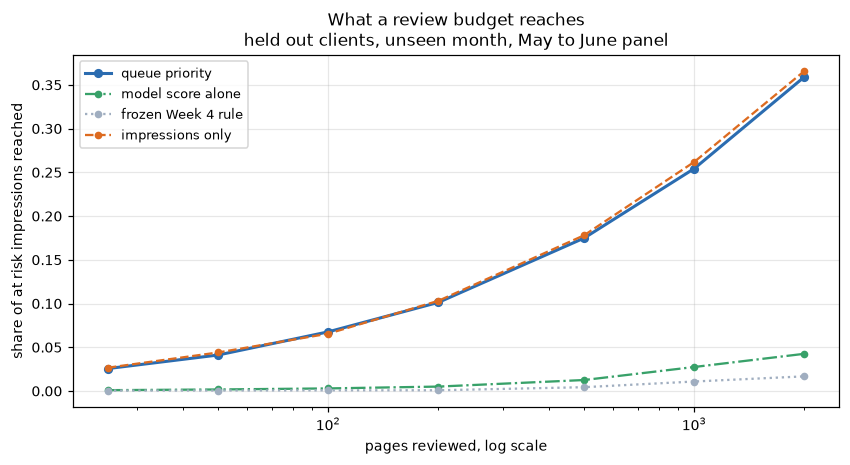

Takeaway: the queue and a plain traffic sort trace almost the same line, so the queue's case is
precision and routing, not reach. The score used alone reaches almost nothing, because it likes
small pages.



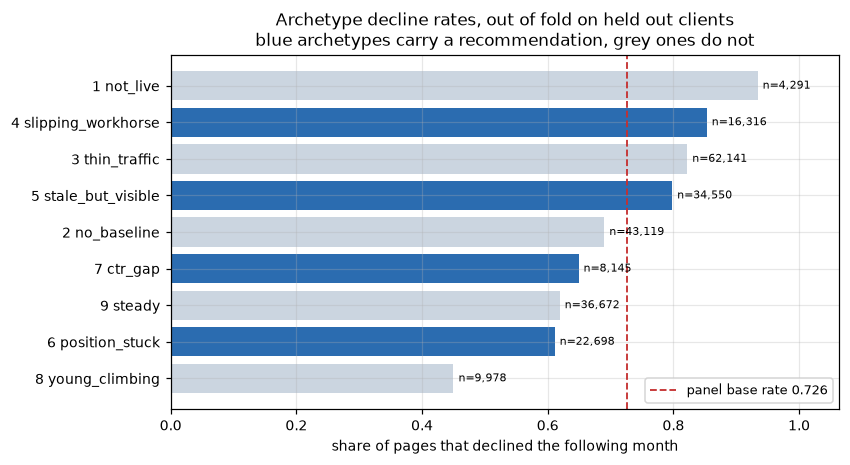

Takeaway: the two hard exclusions sit where they should, and the archetypes that carry a
recommendation are not uniformly above base rate, which is why each carries its own rate here
instead of one headline number.


In [9]:
REVIEW_MINUTES = 20
KS = [25, 50, 100, 200, 500, 1000, 2000]

pool = P3[P3["action"].isin(CARRIES_REC)].copy()
pool["priority"]   = pool["p_decline"] * pool["impr"]
pool["rule_score"] = baseline_w04(pool)
at_risk_total = float(pool.loc[pool["decline"] == 1, "impr"].sum())

ORDERS = {"queue priority":     ["priority"],
          "model score alone":  ["p_decline"],
          "frozen Week 4 rule": ["rule_score", "impr"],
          "impressions only":   ["impr"]}
rows = []
for nm, keys in ORDERS.items():
    o = pool.sort_values(keys, ascending=False)
    for k in KS:
        h = o.head(k)
        got = float(h.loc[h["decline"] == 1, "impr"].sum())
        rows.append({"order": nm, "pages_reviewed": k,
                     "review_hours": round(k * REVIEW_MINUTES / 60, 1),
                     "share_reviewed_that_declined": round(float(h["decline"].mean()), 3),
                     "at_risk_impr_reached": int(got),
                     "share_of_at_risk_reached": round(got / at_risk_total, 4)})
val = pd.DataFrame(rows)

print(f"pool: {len(pool):,} recommendation rows, {int(pool['decline'].sum()):,} of which declined,")
print(f"holding {at_risk_total:,.0f} impressions on pages that did decline. Pool base rate "
      f"{pool['decline'].mean():.3f}.\n")
print("SHARE OF AT RISK IMPRESSIONS REACHED, by review budget")
print(val.pivot(index="pages_reviewed", columns="order", values="share_of_at_risk_reached")
         .round(3).to_string())
print("\nSHARE OF THE REVIEWED PAGES THAT ACTUALLY DECLINED, read against the pool base above")
print(val.pivot(index="pages_reviewed", columns="order", values="share_reviewed_that_declined")
         .round(3).to_string())
print(f"\nreview cost at {REVIEW_MINUTES} minutes a page: "
      + ", ".join(f"{k} pages = {k * REVIEW_MINUTES / 60:.0f}h" for k in (25, 100, 500)))

pv = val.pivot(index="pages_reviewed", columns="order", values="share_of_at_risk_reached")
wins = int((pv["impressions only"] >= pv["queue priority"]).sum())
print(f"\nHEAD TO HEAD: a plain impressions sort reaches at least as much at risk traffic as the queue at "
      f"{wins} of the {len(KS)} budgets.")
print("That is the finding, and it is not the one I wanted. Section 6's closing note reads it properly.")

excl = P3[~P3["action"].isin(CARRIES_REC)]
print(f"\nthe exclusions and no action archetypes hold {len(excl):,} pages carrying "
      f"{excl.loc[excl['decline'] == 1, 'impr'].sum():,.0f} impressions on pages that did decline. The")
print("queue never mentions those, which is a deliberate cost of the floor and the two exclusions.")

import matplotlib.pyplot as plt

# FIGURE 3, what a review budget reaches. The chart that shows the queue is not magic.
fig, ax = plt.subplots(figsize=(7.8, 4.3))
styles = {"queue priority": ("#2b6cb0", "-", 5), "impressions only": ("#dd6b20", "--", 4),
          "model score alone": ("#38a169", "-.", 4), "frozen Week 4 rule": ("#a0aec0", ":", 4)}
for nm in ORDERS:
    d = val[val["order"] == nm]
    c, ls, msz = styles[nm]
    ax.plot(d["pages_reviewed"], d["share_of_at_risk_reached"], marker="o", ms=msz, ls=ls,
            color=c, lw=2.0 if nm == "queue priority" else 1.5, label=nm)
ax.set_xscale("log")
ax.set_xlabel("pages reviewed, log scale")
ax.set_ylabel("share of at risk impressions reached")
ax.set_title("What a review budget reaches\nheld out clients, unseen month, May to June panel", fontsize=11)
ax.legend(fontsize=8.5, loc="upper left")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "w08_capacity_curve.png")); plt.show()
print("Takeaway: the queue and a plain traffic sort trace almost the same line, so the queue's case is")
print("precision and routing, not reach. The score used alone reaches almost nothing, because it likes")
print("small pages.\n")

# FIGURE 4, measured decline rate by archetype. The routing layer's receipt.
fig, ax = plt.subplots(figsize=(7.8, 4.3))
t = tab.sort_values("decline_rate")
cols = ["#2b6cb0" if ACTION[i] in CARRIES_REC else "#cbd5e0" for i in t.index]
ax.barh(t.index.astype(str), t["decline_rate"], color=cols)
ax.axvline(base3, color="#c53030", ls="--", lw=1.2, label=f"panel base rate {base3:.3f}")
for i, (nm, r) in enumerate(t.iterrows()):
    ax.text(r["decline_rate"] + 0.008, i, f"n={int(r['pages']):,}", va="center", fontsize=7.5)
ax.set_xlabel("share of pages that declined the following month")
ax.set_title("Archetype decline rates, out of fold on held out clients\nblue archetypes carry a "
             "recommendation, grey ones do not", fontsize=11)
ax.set_xlim(0, max(0.95, float(t["decline_rate"].max()) + 0.13)); ax.legend(fontsize=8.5, loc="lower right")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "w08_archetype_rates.png")); plt.show()
print("Takeaway: the two hard exclusions sit where they should, and the archetypes that carry a")
print("recommendation are not uniformly above base rate, which is why each carries its own rate here")
print("instead of one headline number.")

### What that table actually says

The queue does not reach more at risk traffic than sorting by impressions. At most review budgets the
plain traffic sort is level with it or marginally ahead. I am stating that plainly because it is the
measured result and the whole point of the exercise was to find out.

What the queue does buy is different, and narrower than a lift number:

1. **Higher precision at the same budget.** Of the pages a reviewer opens, more of them are genuinely
   falling than under a traffic sort. That is fewer wasted reviews, not more traffic protected.
2. **A reason attached to every row.** A traffic sort tells you a page is big. It does not tell you the
   page is on page two, or that the catalogue thinks it was deleted, or that click share is below the
   April median. The routing layer is where most of the practical value sits.
3. **The exclusions.** Ten thousand pages that drew June impressions while the catalogue calls them
   unpublished or deleted never reach a reviewer. A traffic sort ranks them near the top.

And the score used alone is the cautionary line on that chart. Its precision is the highest of the four
and it reaches almost none of the at risk traffic, because a pure decline model prefers small pages. That
is precisely why priority multiplies the score by impressions instead of ranking on the score.

**The no go list.** Things this work does not license, written down so nobody has to infer them:

- No automatic edits, publishing, deletion, redirects, or noindexing. Every row is a human review.
- `p_decline` is never quoted as a chance, a forecast, or a percentage risk.
- No cross client league tables. The ranking is within client for the reason section 6 gives.
- No action on rows below the measurement floor or without a first half baseline.
- No budget or pricing decision from the priority column. It is not money.
- No causal sentence about refreshing. Not "refreshing recovers traffic", ever.
- No autopilot on a model older than two months, and no rerun that nobody reads the monitoring table for.

## 7. Reproducibility and the artifacts the paper embeds

Everything the deployed paper shows is written by the cell below, from this notebook, in this order. The
monitoring table goes with it, because a model that ships without stated retrain triggers is a model
somebody will still be running unchecked in a year.

The queue CSV is deliberately **not** committed. It is per page output on real client content, the repo is
public, and the repo's own leak check blocks it. The metrics JSON and the four figures are the committed
receipts, and they carry every number the paper quotes.

In [10]:
obs_base = [float(p["decline"].mean()) for p in (P1, P2, P3)]
obs_thin = [float((p["impr"] < TRAFFIC_FLOOR).mean()) for p in (P1, P2, P3, LIVE)]
obs_nob  = [float(p["h1_impr"].eq(0).mean()) for p in (P1, P2, P3, LIVE)]
f4       = lad_mean.loc[[i for i in lad_mean.index if i[0].startswith("4 ")]]
auc_fwd  = [float(x) for x in f4.xs("rf_momentum", level=1)["AUC"]]
auc_rule = [float(x) for x in f4.xs("baseline_w04", level=1)["AUC"]]
tr_med, lv_med = float(P3["impr"].median()), float(LIVE["impr"].median())
tr_sc,  lv_sc  = float(P3["p_decline"].mean()), float(LIVE["p_decline"].mean())

mon = pd.DataFrame([
    {"watch": "input", "signal": "share of pages below the 50 impression floor",
     "now": f"{obs_thin[-1]:.3f}", "observed": f"{min(obs_thin):.3f} to {max(obs_thin):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "check the month is complete before anything else"},
    {"watch": "input", "signal": "share of pages with no first half baseline",
     "now": f"{obs_nob[-1]:.3f}", "observed": f"{min(obs_nob):.3f} to {max(obs_nob):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "the no_baseline exclusion is changing size, review the routing"},
    {"watch": "input", "signal": "median impressions, scored month vs training month",
     "now": f"{lv_med:.0f} vs {tr_med:.0f}", "observed": f"ratio {lv_med / tr_med:.2f}",
     "trigger": "ratio outside 0.75 to 1.33", "then": "refit before scoring, do not ship the queue"},
    {"watch": "label", "signal": "base decline rate of the newest labelled pair",
     "now": f"{obs_base[-1]:.3f}", "observed": f"{min(obs_base):.3f} to {max(obs_base):.3f}",
     "trigger": "outside the observed range by more than 0.05",
     "then": "queue precision moves with it, say so before anyone reads the queue"},
    {"watch": "score", "signal": "mean p_decline, scored month vs training month",
     "now": f"{lv_sc:.3f} vs {tr_sc:.3f}", "observed": f"gap {abs(lv_sc - tr_sc):.3f}",
     "trigger": "gap above 0.05", "then": "inputs moved, refit and rerun the drift table"},
    {"watch": "ranking", "signal": "forward AUC on the newest labelled pair",
     "now": f"{auc_fwd[-1]:.3f}", "observed": f"{min(auc_fwd):.3f} to {max(auc_fwd):.3f}",
     "trigger": "below 0.60, or below the frozen rule plus 0.05",
     "then": "stop shipping the model queue, fall back to the rule, investigate"},
    {"watch": "ranking", "signal": "forest AUC minus frozen rule AUC on the same rows",
     "now": f"{auc_fwd[-1] - auc_rule[-1]:.3f}",
     "observed": f"{min(a - b for a, b in zip(auc_fwd, auc_rule)):.3f} to "
                 f"{max(a - b for a, b in zip(auc_fwd, auc_rule)):.3f}",
     "trigger": "at or below zero for two consecutive pairs",
     "then": "retire the model, the rule is cheaper and a person can read it"},
    {"watch": "process", "signal": "reviewer agreement with the reason code",
     "now": "not measurable yet", "observed": "needs a review log",
     "trigger": "below 0.7", "then": "the archetype thresholds are wrong, not the ranking"},
])
print("MONITORING AND RETRAIN TRIGGERS")
print(mon.to_string(index=False))
print("\nRetrain cadence: monthly, on the newest labelled pair. The process row cannot be filled from")
print("the warehouse. It is listed anyway, because leaving it out would imply the model is the only")
print("thing here that decays.\n")

# The queue export. Column allowlist plus a text scan, so nothing leaves that was not meant to.
QCOLS = ["content_hash_id", "client_hash_id", "decision_month", "archetype", "action", "reason_code",
         "rank_in_client", "rank_global", "priority", "p_decline", "impr", "clicks", "ctr",
         "avg_position", "age_days", "mom_impr", "h1_impr", "h2_impr", "days_with_impr",
         "content_type", "main_intent", "word_count", "search_volume", "cpc", "has_market_data",
         "review_required", "scored_by"]
q = queue.copy()
q["decision_month"]  = "2026-06"
q["has_market_data"] = (q["cpc"].fillna(0) > 0) | (q["search_volume"].fillna(0) > 0)
q["review_required"] = True
q["scored_by"]       = "rf_momentum trained on 2026-05 features and a 2026-06 label"
q = q[QCOLS].sort_values(["client_hash_id", "rank_in_client"])
assert list(q.columns) == QCOLS, "queue columns drifted from the allowlist"
for c in ["content_hash_id", "client_hash_id", "decision_month", "archetype", "action", "reason_code",
          "content_type", "main_intent", "scored_by"]:
    s = q[c].astype(str)
    assert not s.str.contains("http", case=False).any(), f"{c} carries a URL"
    assert not s.str.contains("@").any(), f"{c} carries an address"
qpath = os.path.join(OUT, "w08_capstone_queue.csv")
q.to_csv(qpath, index=False)

def _plain(o):
    return o.item() if hasattr(o, "item") else str(o)

metrics = {
    "task": "ML-CAP-01 capstone",
    "lane": "Refresh / Content Opportunity Scoring",
    "release": "hf://datasets/FlyRank/internship-warehouse",
    "question": "which live pages are most likely to lose search impressions next month, and what "
                "should be done about each one",
    "decision_month": "2026-06",
    "model": {"spec": "RandomForestClassifier(n_estimators=200, min_samples_leaf=100, random_state=42)",
              "features": FEATS, "n_features": len(FEATS),
              "label": "next month impressions below 0.8 x this month impressions",
              "trained_on": "P3, 2026-05 features and a 2026-06 label",
              "calibrated": False, "score_use": "ranking only, never a threshold"},
    "baseline": {"spec": "age in days where impr >= 50 and age >= 90 days, else 0",
                 "frozen_in": "ML-06 Week 4"},
    "panels": panels.to_dict("records"),
    "split_ladder_mean": lad_mean.reset_index().to_dict("records"),
    "split_ladder_std": lad_std.reset_index().to_dict("records"),
    "headline": {"random_split_auc": float(lad_mean.loc[("1 random, Mar>Apr", "rf_momentum"), "AUC"]),
                 "forward_auc_pair_1": auc_fwd[0], "forward_auc_pair_2": auc_fwd[1],
                 "forward_baseline_pair_1": auc_rule[0], "forward_baseline_pair_2": auc_rule[1],
                 "reading": "a third of the apparent skill on a random split was client recognition; "
                            "the forward number is the deployable one and it beats the frozen rule "
                            "on both independent pairs"},
    "leakage_audit": {"positive_control_auc": round(leaky, 4), "honest_auc_same_fold": round(honest, 4),
                      "auc_without_mom_impr": round(no_mom, 4), "auc_static_only": round(static, 4),
                      "auc_decoupled_label": round(auc_dec, 4),
                      "decoupled_base_rate": round(float(D["decline_decoupled"].mean()), 4),
                      "momentum_direction": tbl.reset_index().to_dict("records"),
                      "finding": "momentum's direction inverts under a decoupled label, so the ranking "
                                 "survives but the persistence interpretation does not"},
    "calibration": calib.reset_index().to_dict("records"),
    "calibration_finding": "ordering is monotonic across deciles, level is not; score is a rank",
    "survivor_filter": sv.reset_index().to_dict("records"),
    "base_rate_by_pair": bases.to_dict("records"),
    "archetype_definitions": [
        {"archetype": a, "action": act, "reason_code": rsn, "condition": cond}
        for (a, act, rsn, _), cond in zip(ARCH, [
            "is_published is false or is_deleted is true",
            "first half impressions equal zero",
            f"impressions below {TRAFFIC_FLOOR}",
            f"impressions at least {BIG_TRAFFIC} and mom_impr below {MOM_FALL}",
            f"age at least {AGE_LINE} days and mom_impr below 1.0",
            f"average position between {POS_LO} and {POS_HI}",
            f"average position at most 10 and ctr below {CTR_FLOOR:.2f} percent",
            f"age below {AGE_LINE} days and mom_impr at least 1.0",
            "no earlier condition matched"])],
    "archetype_evaluation": "first match wins in the listed order, so every recommendation inherits "
                            "the 50 impression floor and both hard exclusions",
    "archetype_rates_out_of_fold": tab.reset_index().to_dict("records"),
    "capacity_curve": val.to_dict("records"),
    "capacity_finding": f"a plain impressions sort reaches at least as much at risk traffic as the "
                        f"queue at {wins} of {len(KS)} review budgets; the queue's measured advantage "
                        f"is precision and routing, not reach",
    "monitor_triggers": mon.to_dict("records"),
    "queue": {"rows": len(q), "clients": int(q["client_hash_id"].nunique()),
              "share_of_live_pages": round(len(q) / len(LIVE), 4),
              "rows_by_action": queue["action"].value_counts().to_dict(),
              "ranked_by": "priority = p_decline x impressions, ranked inside each client"},
    "assumptions": {"review_minutes_per_page": REVIEW_MINUTES,
                    "review_minutes_source": "assumption, not measured in this data",
                    "decline_threshold": 0.8, "decline_threshold_source": "chosen, not derived",
                    "value_per_visit": "client specific, deliberately not assumed"},
    "no_go": ["automatic edits, publishing, deletion, redirects or noindexing",
              "p_decline quoted as a chance or a forecast", "cross client league tables",
              "action below the measurement floor or without a first half baseline",
              "budget or pricing decisions from the priority column",
              "any causal sentence about refreshing",
              "autopilot on a model older than two months"],
    "claim_language": ["observed", "measured", "associated with", "directional", "decision support"],
    "exports": {"queue_csv": "work/outputs/w08_capstone_queue.csv (gitignored on purpose)",
                "metrics_json": "work/outputs/w08_capstone_metrics.json",
                "figures": ["work/figures/w08_ladder.png", "work/figures/w08_forward_stability.png",
                            "work/figures/w08_capacity_curve.png",
                            "work/figures/w08_archetype_rates.png"]},
    "data_credit": "Built on the FlyRank ML Internship dataset, https://flyrank.ai",
}
mpath = os.path.join(OUT, "w08_capstone_metrics.json")
with open(mpath, "w") as f:
    json.dump(metrics, f, indent=2, default=_plain)

print("WROTE")
for p in (qpath, mpath, os.path.join(FIG, "w08_ladder.png"),
          os.path.join(FIG, "w08_forward_stability.png"),
          os.path.join(FIG, "w08_capacity_curve.png"),
          os.path.join(FIG, "w08_archetype_rates.png")):
    print(f"  {os.path.relpath(p, ROOT):50s} {os.path.getsize(p) / 1024:8.1f} KB")
print(f"\nqueue: {len(q):,} rows, {q['client_hash_id'].nunique()} clients, {len(QCOLS)} columns, every")
print("identifier a warehouse pseudonym. The CSV stays out of git; the JSON and the four figures are")
print("the committed receipts, and the deployed paper quotes nothing that is not in them.")

MONITORING AND RETRAIN TRIGGERS
  watch                                             signal                now           observed                                        trigger                                                                then
  input       share of pages below the 50 impression floor              0.422     0.343 to 0.438   outside the observed range by more than 0.05                    check the month is complete before anything else
  input         share of pages with no first half baseline              0.112     0.112 to 0.199   outside the observed range by more than 0.05      the no_baseline exclusion is changing size, review the routing
  input median impressions, scored month vs training month           91 vs 80         ratio 1.14                     ratio outside 0.75 to 1.33                         refit before scoring, do not ship the queue
  label      base decline rate of the newest labelled pair              0.726     0.503 to 0.726   outside the observed 

WROTE
  work/outputs/w08_capstone_queue.csv                 29390.3 KB
  work/outputs/w08_capstone_metrics.json                 23.8 KB
  work/figures/w08_ladder.png                            62.5 KB
  work/figures/w08_forward_stability.png                 55.9 KB
  work/figures/w08_capacity_curve.png                    59.9 KB
  work/figures/w08_archetype_rates.png                   50.1 KB

queue: 82,877 rows, 47 clients, 27 columns, every
identifier a warehouse pseudonym. The CSV stays out of git; the JSON and the four figures are
the committed receipts, and the deployed paper quotes nothing that is not in them.


## Self-check

- [x] **Every section filled, markdown thinking and the code behind it.** Seven sections, each with the
      prose that makes the argument and the cell that produces the number it rests on.
- [x] **Runs top to bottom with no errors.** Executed as one pass; the panel asserts on P1 and P2 would
      stop the run if the frames drifted from the Week 5 and Week 6 notebooks, and they did not.
- [x] **No client names, URLs, or private queries anywhere.** Every identifier is a warehouse pseudonym.
      The queue export is column allowlisted and text scanned for anything URL or address shaped, and
      the CSV is gitignored rather than committed.
- [x] **Careful words.** Observed, measured, associated with, directional, decision support. No causal
      sentence about refreshing appears in this notebook or in the paper.
- [x] **Committed under `work/notebooks/`** alongside every weekly notebook it draws on.
- [x] **The deployed paper carries all nine sections** in the required order, Abstract first,
      Acknowledgments and data credit last with the https://flyrank.ai link.
- [x] **ML-12 in the closing cells below.**

### What this notebook does not claim

Three specific things, so the list is checkable rather than a gesture:

1. **That the model is impressive.** A forward AUC in the high 0.6s is a modest signal. The claim is that
   it is measurably better than the frozen rule on unseen clients in an unseen month, twice.
2. **That the queue protects more traffic than a spreadsheet sort.** Section 6 measured that and it does
   not. The advantage is precision and routing.
3. **That falling pages keep falling.** The leakage hunt broke that reading. The ordering survived; the
   explanation did not, and it is left out.

## ML-12, the ship it cells

### A. Five minute demo outline

Timings are the whole point of the exercise, so they are written as a budget rather than a wish.

**0:00 to 0:40, the problem, no slides.** A content team has more pages than review hours. Every month
some pages start losing search impressions, and nobody knows which ones until the traffic has already
gone. The question is not "how is the site doing", it is "which twenty pages do I open on Monday".

**0:40 to 1:30, the honest number, straight to the chart.** Show `w08_ladder.png`. Point at the leftmost
bar and say a random split flatters this model by about a tenth of an AUC point. Point at the rightmost
bars and say that is the number a deployed queue would actually deliver, and it beats the rule the team
uses today at every rung. Do not defend the size of it. Say it is modest and say it is real.

**1:30 to 2:20, why anyone should believe the number.** One sentence per test. No client is on both sides
of any split. The forward test ran twice on independent month pairs. I handed the model the label's own
ingredient as a positive control to prove the harness would catch a leak. When I broke the arithmetic
between the label and my best feature, the direction inverted, so I stopped claiming I knew why the
feature works.

**2:20 to 3:30, from a score to a decision.** Show `w08_archetype_rates.png`. Nine buckets, first match
wins, two hard exclusions at the top. Land the exclusion with the number: about ten thousand pages drew
impressions in June while the catalogue called them unpublished or deleted, and every one of those is
dropped before a reviewer sees the list. Then show the queue preview and read one row out loud as a
sentence a person could act on.

**3:30 to 4:20, the part most demos skip.** Show `w08_capacity_curve.png`. Say the queue line and the
plain traffic sort line almost overlap, so the queue does not protect more traffic than sorting by
impressions. What it buys is a cleaner review list and a reason on every row. Then the monitoring table:
two triggers that would take this model out of production, including the one where the rule wins and the
model gets retired.

**4:20 to 5:00, what I would do next and what I will not do.** Next: a review log, so reviewer agreement
becomes measurable, and a third month pair. Not next: calibrating the score into a percentage, because
nothing downstream needs a probability, and any automation, because there is no experiment here and
therefore no causal ground to stand on.

**The one question to expect.** "Why not just sort by traffic?" Answer it with the capacity chart already
on screen, then with the exclusions. That question is the strongest one in the room and the paper answers
it rather than avoiding it.

### B. The social cut

> Spent a month building a model that ranks which web pages are about to lose search traffic.
>
> On a random split it scored 0.76 AUC. I nearly wrote that number down.
>
> Then I split by client instead of by row. 0.67. A third of the "skill" was the model recognising which
> client a page belonged to, not reading how the page behaves.
>
> Three more things I found by attacking my own work:
>
> Handed the model the answer as a positive control, to prove my test harness could detect a leak at all.
> It could. Worth knowing before trusting anything else.
>
> Broke the arithmetic my label and my best feature shared. The accuracy held; the direction of the effect
> inverted. So the ranking is real and my explanation for it was not. That sentence is now out of the paper.
>
> Checked whether the ranked queue beats sorting by traffic in a spreadsheet. On traffic protected, it
> does not. It wins on precision and on attaching a reason to every row, which is a smaller and truer
> claim than the one I set out to make.
>
> The model is not the deliverable. The queue is, and it says which pages to skip.
>
> Built on the FlyRank ML Internship dataset. Paper and notebooks in the repo.

### C. Three sentences for an employer

I built a monthly ranking of which live web pages are most likely to lose search impressions next month,
validated it on clients and a month the model had never seen, and turned the score into a review queue
where every row carries a reason and an action. The forward tested model beats the frozen heuristic it
replaces on two independent month pairs, and I report the forward number rather than the random split
number that was a tenth of an AUC point better and would not have survived deployment. The work that took
longest was disproving my own results: a positive control on the validation harness, a decoupled label
that inverted a feature's direction and cost me a claim, and a head to head against a plain traffic sort
that the queue only partly won.